<a href="https://colab.research.google.com/github/karlinnn/ML-Practice/blob/main/FS_Normalisation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [12]:
df=pd.read_csv("/content/winequality-red.csv",header=None,usecols=[1,10,11],skiprows=1)
df.columns=["Volatile-Acidity","Alcohol","Quality"]
df.head()

,Volatile-Acidity,Alcohol,Quality
0,0.70,9.4,5
1,0.88,9.8,5
2,0.76,9.8,5
3,0.28,9.8,6
4,0.70,9.4,5


<Axes: xlabel='Alcohol', ylabel='Density'>

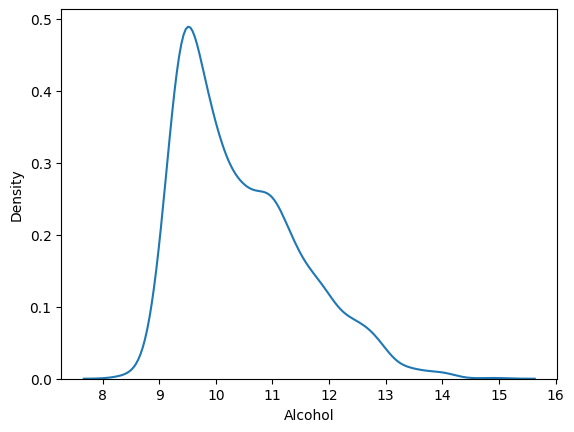

In [13]:
#plotting pdf

sns.kdeplot(df["Alcohol"])

<Axes: xlabel='Volatile-Acidity', ylabel='Density'>

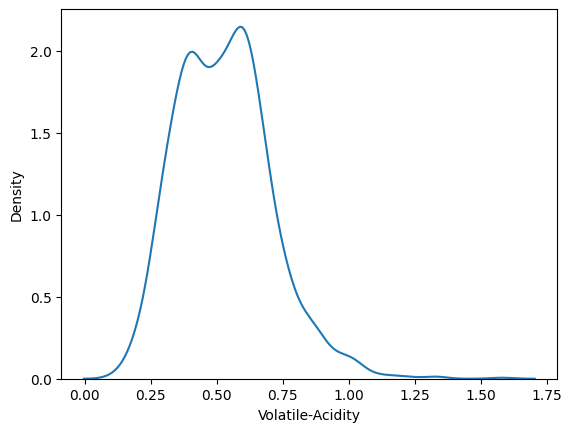

In [14]:
sns.kdeplot(df["Volatile-Acidity"])

<Axes: xlabel='Alcohol', ylabel='Volatile-Acidity'>

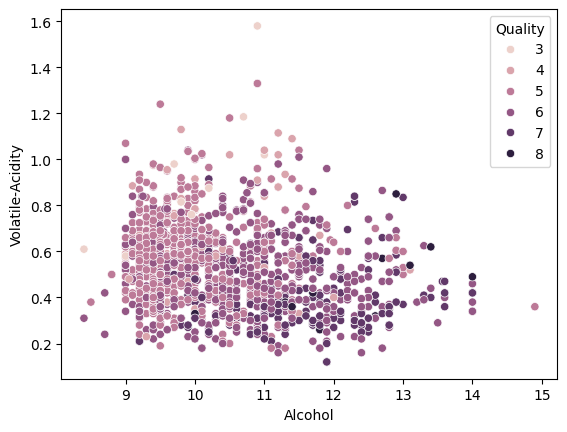

In [18]:
# The original color_dict was incomplete. To avoid the ValueError,
# we can let Seaborn automatically assign colors based on the 'Quality' hue.
# If you wish to use a custom palette, ensure it includes all unique 'Quality' values.
# color_dict={1:'red',3:'green',2:'blue'} # Original incomplete dictionary
sns.scatterplot(x=df['Alcohol'],y=df['Volatile-Acidity'],hue=df['Quality'])

In [19]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(df.drop('Quality',axis=1),
                                               df['Quality'],
                                               test_size=0.3,
                                               random_state=0)
X_train.shape,X_test.shape

((1119, 2), (480, 2))

In [24]:
from sklearn.preprocessing import MinMaxScaler

scaler=MinMaxScaler()

#fit the scaler to the train set, it will learn the parameters
scaler.fit(X_train)

#transform train and test sets
X_train_scaled=scaler.transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [25]:
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

In [22]:
np.round(X_train.describe(), 1)

,Volatile-Acidity,Alcohol
count,1119.0,1119.0
mean,0.5,10.4
std,0.2,1.1
min,0.1,8.4
25%,0.4,9.5
50%,0.5,10.1
75%,0.6,11.0
max,1.6,14.9


In [26]:
np.round(X_train_scaled.describe(), 1)

,Volatile-Acidity,Alcohol
count,1119.0,1119.0
mean,0.3,0.3
std,0.1,0.2
min,0.0,0.0
25%,0.2,0.2
50%,0.3,0.3
75%,0.4,0.4
max,1.0,1.0


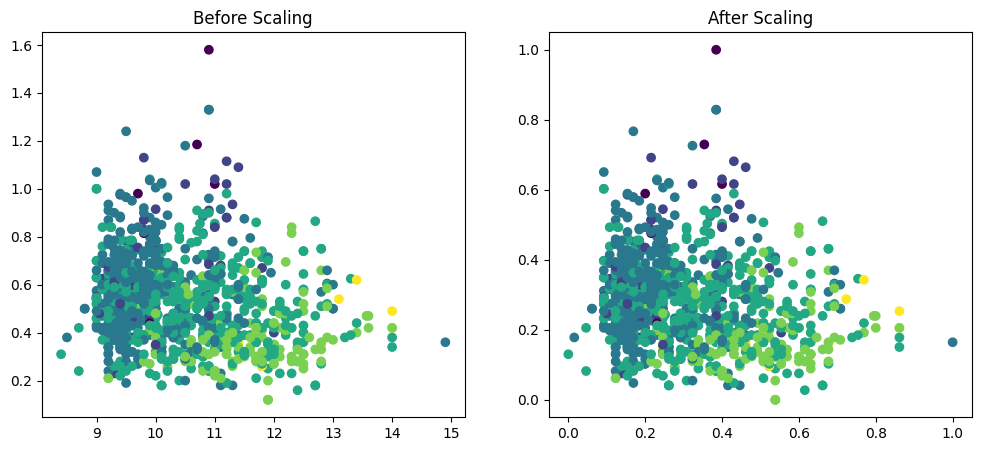

In [27]:
fig, (ax1,ax2) = plt.subplots(ncols=2, figsize=(12, 5))

ax1.scatter(X_train['Alcohol'],X_train['Volatile-Acidity'],c=y_train)
ax1.set_title("Before Scaling")
ax2.scatter(X_train_scaled['Alcohol'],X_train_scaled['Volatile-Acidity'],c=y_train)
ax2.set_title("After Scaling")
plt.show()